In [53]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns


In [54]:
# 1. DATA LOADING AND CLEANING
faostat = pd.read_csv('FAOSTAT_data_en_4-29-2026.csv')
energy = pd.read_csv('owid-energy-data.csv')
print("FAOSTAT Data Loaded: ", faostat.shape)
print("Energy Data Loaded: ", energy.shape)

FAOSTAT Data Loaded:  (16706, 14)
Energy Data Loaded:  (23377, 130)


In [55]:
# Clean climate data (Extracting full meteorological year anomalies)
climate_df = faostat[(faostat['Element'] == 'Temperature change') & (faostat['Months'] == 'Meteorological year')]
climate_df = climate_df[['Area', 'Year', 'Value']].rename(columns={'Area': 'country', 'Year': 'year', 'Value': 'temp_change'})
print("Cleaned Climate Data Shape: ", climate_df.shape)

Cleaned Climate Data Shape:  (8353, 3)


In [56]:
# Map country names to ensure accurate matching across sources
name_mapping = {
    'United States of America': 'United States',
    'China, mainland': 'China',
    'United Kingdom of Great Britain and Northern Ireland': 'United Kingdom',
    'Russian Federation': 'Russia',
    'Viet Nam': 'Vietnam',
    'Republic of Korea': 'South Korea',
    'Iran (Islamic Republic of)': 'Iran',
    'Venezuela (Bolivarian Republic of)': 'Venezuela',
    'Bolivia (Plurinational State of)': 'Bolivia',
    'Syrian Arab Republic': 'Syria',
    'United Republic of Tanzania': 'Tanzania',
    'Democratic Republic of the Congo': 'Democratic Republic of Congo',
    'Congo': 'Congo'
}
climate_df['country'] = climate_df['country'].replace(name_mapping)
energy['country'] = energy['country'].replace(name_mapping)
print("Country names standardized for merging.")

Country names standardized for merging.


In [57]:
# Merge datasets together
merged = pd.merge(climate_df, energy, on=['country', 'year'], how='inner')
merged['gdp_per_capita'] = merged['gdp'] / merged['population']
merged['electricity_demand_per_capita'] = merged['electricity_demand'] / merged['population']
print("Merged Data Shape: ", merged.shape)

Merged Data Shape:  (6765, 132)


C:\Users\Sunny\AppData\Local\Temp\ipykernel_11720\1426688139.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged['gdp_per_capita'] = merged['gdp'] / merged['population']


In [58]:
# Select target columns and drop rows with critical missing values
output_cols = ['country', 'year', 'temp_change', 'electricity_demand_per_capita', 'gdp_per_capita', 'population']
analysis_data = merged[output_cols].dropna(subset=['temp_change', 'electricity_demand_per_capita'])
print("Final Analysis Data Shape: ", analysis_data.shape)

Final Analysis Data Shape:  (5022, 6)


In [59]:
# Save the unified cleaned dataset for your project file directory
analysis_data.to_csv('climate_energy_analysis_data.csv', index=False)
print("Cleaned and merged dataset saved as 'climate_energy_analysis_data.csv'.")

Cleaned and merged dataset saved as 'climate_energy_analysis_data.csv'.


In [60]:
# TASK 1: STATISTICAL ANALYSIS ON CLIMATE-ENERGY VARIABLES
print("\n=== TASK 1: Descriptive Statistical Summary ===")
print(analysis_data[['temp_change', 'electricity_demand_per_capita', 'gdp_per_capita']].describe())


=== TASK 1: Descriptive Statistical Summary ===
       temp_change  electricity_demand_per_capita  gdp_per_capita
count  5022.000000                   5.022000e+03     3755.000000
mean      1.101646                   3.985791e-06    16412.138439
std       0.594155                   5.316528e-06    17376.936550
min      -0.922000                   8.889736e-09      421.564890
25%       0.697250                   6.491603e-07     4073.012721
50%       1.024000                   2.443318e-06    10787.099241
75%       1.434000                   5.361768e-06    23728.223796
max       3.697000                   5.604873e-05   163531.400281


In [61]:
# TASK 2: HYPOTHESIS VALIDATION USING CORRELATION & REGRESSION
print("\n=== TASK 2: Hypothesis Testing ===")

# Part A: Climate-Segmented Pearson Correlation Testing
target_countries = ['India', 'Brazil', 'Egypt', 'Spain', 'Canada', 'Sweden', 'Australia']

print("\n[Part A: Pearson Correlation Coefficients]")
for country in target_countries:
    sub = analysis_data[analysis_data['country'] == country]
    if len(sub) >= 10:
        r_coef, p_val = stats.pearsonr(sub['temp_change'], sub['electricity_demand_per_capita'])
        sig = "Significant" if p_val < 0.05 else "Not Significant"
        print(f"  * {country:<12} -> r = {r_coef:6.3f} | p-value = {p_val:6.5f} ({sig})")

# Part B: Multi-Variable Controlled OLS Regression via pure Matrix Algebra
print("\n[Part B: Multi-Variable OLS Regression Model (Controlled for GDP & Pop)]")
def run_ols_regression(df, country_name):
    sub_df = df[df['country'] == country_name].dropna(subset=['gdp_per_capita', 'population'])
    if len(sub_df) < 5:
        return
    
    y = sub_df['electricity_demand_per_capita'].values
    X_vars = sub_df[['temp_change', 'gdp_per_capita', 'population']].values
    
    # Append a column of ones to serve as the intercept term (constant)
    X = np.column_stack([np.ones(X_vars.shape[0]), X_vars])
    
    # Linear Algebra OLS formula: Beta = (X^T * X)^(-1) * X^T * y
    beta = np.linalg.inv(X.T @ X) @ X.T @ y
    residuals = y - X @ beta
    
    # Compute Significance Metrics
    n, p = X.shape
    dof = n - p
    s2 = (residuals.T @ residuals) / dof
    cov_beta = s2 * np.linalg.inv(X.T @ X)
    se_beta = np.sqrt(np.diagonal(cov_beta))
    t_stats = beta / se_beta
    p_values = [2 * (1 - stats.t.cdf(np.abs(t), dof)) for t in t_stats]
    
    # R-squared value
    ss_tot = np.sum((y - np.mean(y))**2)
    ss_res = np.sum(residuals**2)
    r2 = 1 - (ss_res / ss_tot)
    
    print(f"\nRegression Report for {country_name} (R² = {r2:.3f}):")
    labels = ['Intercept (Intercept)', 'temp_change (Climate)', 'gdp_per_capita (Economy)', 'population (Demographics)']
    for lbl, b, se, t, p_v in zip(labels, beta, se_beta, t_stats, p_values):
        print(f"  {lbl:<30}: Coef = {b:12.4f} | Std.Err = {se:12.4f} | p-value = {p_v:8.5f}")

# Run controlled regression analysis on two representative baseline climates
run_ols_regression(analysis_data, 'India')
run_ols_regression(analysis_data, 'Sweden')


=== TASK 2: Hypothesis Testing ===

[Part A: Pearson Correlation Coefficients]
  * India        -> r =  0.485 | p-value = 0.01196 (Significant)
  * Brazil       -> r =  0.706 | p-value = 0.00006 (Significant)
  * Egypt        -> r =  0.624 | p-value = 0.00065 (Significant)
  * Spain        -> r =  0.338 | p-value = 0.04670 (Significant)
  * Canada       -> r = -0.428 | p-value = 0.02908 (Significant)
  * Sweden       -> r = -0.589 | p-value = 0.00020 (Significant)
  * Australia    -> r = -0.571 | p-value = 0.00229 (Significant)

[Part B: Multi-Variable OLS Regression Model (Controlled for GDP & Pop)]

Regression Report for India (R² = 0.996):
  Intercept (Intercept)         : Coef =       0.0000 | Std.Err =       0.0000 | p-value =  0.19031
  temp_change (Climate)         : Coef =      -0.0000 | Std.Err =       0.0000 | p-value =  0.03610
  gdp_per_capita (Economy)      : Coef =       0.0000 | Std.Err =       0.0000 | p-value =  0.00000
  population (Demographics)     : Coef =      -0

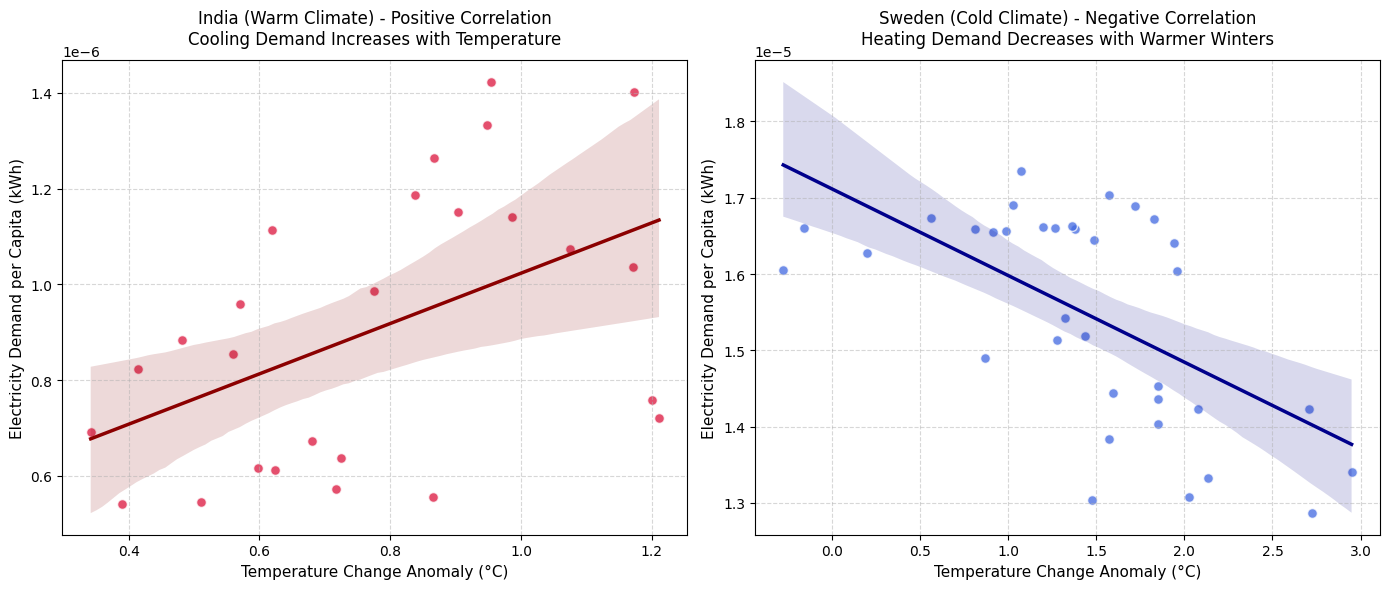

In [62]:
# 3. GENERATE VISUAL EVIDENCE FOR YOUR PROJECT REPORT
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Draw Left Plot: India (Warm Environment) onto ax1
ax1, ax2 = axes

# 1. Draw Left Plot: India (Warm Environment) onto ax1
sns.regplot(
    data=analysis_data[analysis_data['country'] == 'India'], 
    x='temp_change', 
    y='electricity_demand_per_capita', 
    ax=ax1, 
    color='crimson', 
    scatter_kws={'s': 50, 'alpha': 0.75, 'edgecolor': 'w'}, 
    line_kws={'color': 'darkred', 'linewidth': 2.5}
)
ax1.set_title('India (Warm Climate) - Positive Correlation\nCooling Demand Increases with Temperature', fontsize=12, pad=12)
ax1.set_xlabel('Temperature Change Anomaly (°C)', fontsize=11)
ax1.set_ylabel('Electricity Demand per Capita (kWh)', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)

# 2. Draw Right Plot: Sweden (Cold Environment) onto ax2
sns.regplot(
    data=analysis_data[analysis_data['country'] == 'Sweden'], 
    x='temp_change', 
    y='electricity_demand_per_capita', 
    ax=ax2, 
    color='royalblue', 
    scatter_kws={'s': 50, 'alpha': 0.75, 'edgecolor': 'w'}, 
    line_kws={'color': 'darkblue', 'linewidth': 2.5}
)
ax2.set_title('Sweden (Cold Climate) - Negative Correlation\nHeating Demand Decreases with Warmer Winters', fontsize=12, pad=12)
ax2.set_xlabel('Temperature Change Anomaly (°C)', fontsize=11)
ax2.set_ylabel('Electricity Demand per Capita (kWh)', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)

# 4. Enforce strict padding boundaries to prevent edge cropping
plt.tight_layout()

# 5. Save and present the layout
plt.savefig('climate_energy_trends_fixed.png', dpi=300, bbox_inches='tight')
plt.show()